# Data Augmentation Adaptativo para Clasificación de Escarabajos

Este notebook implementa data augmentation adaptativo basado en la cantidad de imágenes por clase.

## Estrategia Adaptativa Optimizada:
- **≤80 imágenes**: 18 variantes (transformaciones moderadas-fuertes)
- **≤120 imágenes**: 12 variantes (transformaciones moderadas)
- **≤180 imágenes**: 9 variantes (transformaciones moderadas-leves)
- **≤400 imágenes**: 6 variantes (transformaciones leves)
- **>400 imágenes**: 3 variantes (transformaciones muy leves)
- **unknown_beetle**: 4 variantes (transformaciones muy leves) - Regla especial

## Objetivo:
Balancear el dataset para mejorar el rendimiento del modelo de clasificación y reducir el sobreentrenamiento.

## Estructura de Carpetas:
- **Originales**: `cropped_beetles/images/` (no se modifican)
- **Aumentadas**: `cropped_beetles/images_augmented/` (solo aumentadas)

## 1. Importar Librerías

In [4]:
import os
import random
import numpy as np
from PIL import Image
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF

# Configurar seed para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.5.1
Torchvision version: 0.20.1
Device: CUDA


## 2. Configuración del Dataset

In [5]:
# Configuración
DATA_DIR = 'cropped_beetles/images'
OUTPUT_DIR = 'cropped_beetles/images_augmented'  # Carpeta SEPARADA para aumentadas

# Configuración de augmentation adaptativo OPTIMIZADA
AUGMENTATION_CONFIG = {
    'low': {
        'threshold': 80,
        'num_augmentations': 18,
        'level': 'moderate-strong',
        'description': 'Clases pequeñas - Aumentar significativamente'
    },
    'medium_low': {
        'threshold': 120,
        'num_augmentations': 12,
        'level': 'moderate',
        'description': 'Clases medianas-pequeñas'
    },
    'medium': {
        'threshold': 180,
        'num_augmentations': 9,
        'level': 'moderate-light',
        'description': 'Clases medianas'
    },
    'high': {
        'threshold': 400,
        'num_augmentations': 6,
        'level': 'light',
        'description': 'Clases grandes'
    },
    'very_high': {
        'threshold': float('inf'),
        'num_augmentations': 3,
        'level': 'very-light',
        'description': 'Clases muy grandes'
    }
}

# Regla especial para unknown_beetle (clase heterogénea)
SPECIAL_CLASS_RULES = {
    'unknown_beetle': {
        'num_augmentations': 4,
        'level': 'very-light',
        'description': 'Clase heterogénea - Transformaciones conservadoras'
    }
}

print("=" * 80)
print("CONFIGURACIÓN DE DATA AUGMENTATION OPTIMIZADA")
print("=" * 80)
print("\n📊 Estrategia Adaptativa por Umbral:")
print("-" * 80)
for category, config in AUGMENTATION_CONFIG.items():
    if config['threshold'] == float('inf'):
        print(f"  {category.upper():15s} (> 400 imgs): {config['num_augmentations']:2d} variantes "
              f"[{config['level']:20s}] - {config['description']}")
    else:
        print(f"  {category.upper():15s} (≤ {config['threshold']:3.0f} imgs): {config['num_augmentations']:2d} variantes "
              f"[{config['level']:20s}] - {config['description']}")

print("\n🎯 Reglas Especiales por Clase:")
print("-" * 80)
for class_name, config in SPECIAL_CLASS_RULES.items():
    print(f"  {class_name:30s}: {config['num_augmentations']:2d} variantes "
          f"[{config['level']:20s}] - {config['description']}")
print("=" * 80)

# Crear carpeta de salida si no existe
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"\n✓ Carpeta creada: {OUTPUT_DIR}")
else:
    print(f"\n✓ Carpeta de salida existente: {OUTPUT_DIR}")

CONFIGURACIÓN DE DATA AUGMENTATION OPTIMIZADA

📊 Estrategia Adaptativa por Umbral:
--------------------------------------------------------------------------------
  LOW             (≤  80 imgs): 18 variantes [moderate-strong     ] - Clases pequeñas - Aumentar significativamente
  MEDIUM_LOW      (≤ 120 imgs): 12 variantes [moderate            ] - Clases medianas-pequeñas
  MEDIUM          (≤ 180 imgs):  9 variantes [moderate-light      ] - Clases medianas
  HIGH            (≤ 400 imgs):  6 variantes [light               ] - Clases grandes
  VERY_HIGH       (> 400 imgs):  3 variantes [very-light          ] - Clases muy grandes

🎯 Reglas Especiales por Clase:
--------------------------------------------------------------------------------
  unknown_beetle                :  4 variantes [very-light          ] - Clase heterogénea - Transformaciones conservadoras

✓ Carpeta creada: cropped_beetles/images_augmented


## 3. Analizar Dataset Original

In [6]:
def analyze_dataset(data_dir, only_original=True):
    """
    Analiza la distribución del dataset
    
    Args:
        data_dir: Directorio a analizar
        only_original: Si True, solo cuenta imágenes originales (sin _aug_)
    """
    class_distribution = {}
    
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        
        if not os.path.isdir(class_path):
            continue
        
        # Contar imágenes (jpg, jpeg, png)
        image_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        # Filtrar solo originales si se solicita
        if only_original:
            image_files = [f for f in image_files if '_aug_' not in f]
        
        class_distribution[class_name] = len(image_files)
    
    return class_distribution

# Analizar dataset ORIGINAL (sin aumentadas previas)
class_dist = analyze_dataset(DATA_DIR, only_original=True)

print("Distribución Original del Dataset (SOLO ORIGINALES):")
print("-" * 60)
for class_name, count in sorted(class_dist.items(), key=lambda x: x[1]):
    print(f"{class_name:35s}: {count:4d} imágenes")
print("-" * 60)
print(f"Total de géneros: {len(class_dist)}")
print(f"Total de imágenes originales: {sum(class_dist.values())}")
print(f"Promedio por clase: {np.mean(list(class_dist.values())):.1f}")
print(f"Mediana por clase: {np.median(list(class_dist.values())):.1f}")
print(f"Min: {min(class_dist.values())}, Max: {max(class_dist.values())}")

Distribución Original del Dataset (SOLO ORIGINALES):
------------------------------------------------------------
deltochilum_guildingii             :   50 imágenes
tetraechma_lituratus               :   60 imágenes
canthon_acutoides                  :   76 imágenes
uroxys_                            :   92 imágenes
canthidium_01h                     :  120 imágenes
canthon_septemmaculatus            :  141 imágenes
canthon_juvencus                   :  156 imágenes
ontophagus_lebasi                  :  160 imágenes
dichotomius_tristis                :  171 imágenes
canthon_cyanellus                  :  175 imágenes
ontophagus_bidentatus              :  237 imágenes
unknown_beetle                     :  369 imágenes
stenotothorax_                     :  762 imágenes
------------------------------------------------------------
Total de géneros: 13
Total de imágenes originales: 2569
Promedio por clase: 197.6
Mediana por clase: 156.0
Min: 50, Max: 762


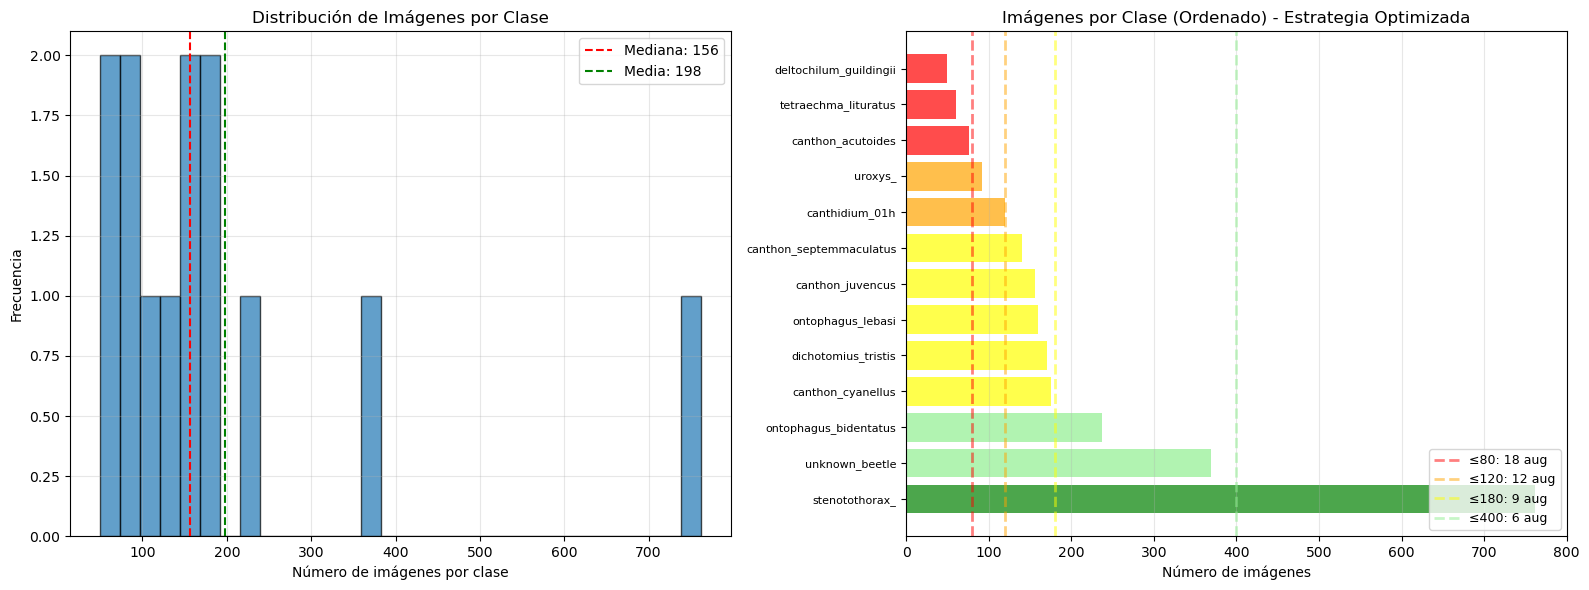

In [7]:
# Visualizar distribución
plt.figure(figsize=(16, 6))

# Histograma
plt.subplot(1, 2, 1)
counts = list(class_dist.values())
plt.hist(counts, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Número de imágenes por clase')
plt.ylabel('Frecuencia')
plt.title('Distribución de Imágenes por Clase')
plt.axvline(np.median(counts), color='red', linestyle='--', label=f'Mediana: {np.median(counts):.0f}')
plt.axvline(np.mean(counts), color='green', linestyle='--', label=f'Media: {np.mean(counts):.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Barplot ordenado con nueva estrategia
plt.subplot(1, 2, 2)
sorted_classes = sorted(class_dist.items(), key=lambda x: x[1], reverse=True)
class_names = [c[0] for c in sorted_classes]
class_counts = [c[1] for c in sorted_classes]

# Colores según nueva estrategia
colors = ['red' if c <= 80 else 'orange' if c <= 120 else 'yellow' if c <= 180 
          else 'lightgreen' if c <= 400 else 'green' for c in class_counts]

plt.barh(range(len(class_names)), class_counts, color=colors, alpha=0.7)
plt.yticks(range(len(class_names)), class_names, fontsize=8)
plt.xlabel('Número de imágenes')
plt.title('Imágenes por Clase (Ordenado) - Estrategia Optimizada')
plt.axvline(80, color='red', linestyle='--', alpha=0.5, linewidth=2, label='≤80: 18 aug')
plt.axvline(120, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='≤120: 12 aug')
plt.axvline(180, color='yellow', linestyle='--', alpha=0.5, linewidth=2, label='≤180: 9 aug')
plt.axvline(400, color='lightgreen', linestyle='--', alpha=0.5, linewidth=2, label='≤400: 6 aug')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 4. Definir Transformaciones Adaptativas

In [8]:
class AdaptiveAugmentation:
    """
    Clase para aplicar transformaciones adaptativas según el nivel de datos.
    """
    
    def __init__(self, level='moderate'):
        self.level = level
        self.base_size = 224
    
    def get_moderate_strong_transforms(self):
        """Transformaciones moderadas-fuertes para clases con pocas imágenes (≤80)"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.25),
            transforms.RandomRotation(degrees=25),
            transforms.RandomAffine(
                degrees=18,
                translate=(0.12, 0.12),
                scale=(0.82, 1.18),
                shear=12
            ),
            transforms.ColorJitter(
                brightness=0.35,
                contrast=0.35,
                saturation=0.35,
                hue=0.15
            ),
            transforms.RandomPerspective(distortion_scale=0.25, p=0.4),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.8)),
            transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.25),
        ]
    
    def get_moderate_transforms(self):
        """Transformaciones moderadas para clases medianas-pequeñas (≤120)"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=20),
            transforms.RandomAffine(
                degrees=15,
                translate=(0.1, 0.1),
                scale=(0.85, 1.15),
                shear=10
            ),
            transforms.ColorJitter(
                brightness=0.3,
                contrast=0.3,
                saturation=0.3,
                hue=0.1
            ),
            transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
        ]
    
    def get_moderate_light_transforms(self):
        """Transformaciones moderadas-leves para clases medianas (≤180)"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.RandomAffine(
                degrees=10,
                translate=(0.08, 0.08),
                scale=(0.9, 1.1),
                shear=5
            ),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            ),
            transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
        ]
    
    def get_light_transforms(self):
        """Transformaciones leves para clases grandes (≤400)"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.15,
                hue=0.03
            ),
            transforms.RandomAffine(
                degrees=5,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05)
            ),
        ]
    
    def get_very_light_transforms(self):
        """Transformaciones muy leves para clases muy grandes (>400) y unknown_beetle"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=8),
            transforms.ColorJitter(
                brightness=0.1,
                contrast=0.1,
                saturation=0.1,
                hue=0.02
            ),
            transforms.RandomAffine(
                degrees=3,
                translate=(0.03, 0.03),
                scale=(0.97, 1.03)
            ),
        ]
    
    def get_transforms(self):
        """Obtener las transformaciones según el nivel"""
        if self.level == 'moderate-strong':
            return self.get_moderate_strong_transforms()
        elif self.level == 'moderate':
            return self.get_moderate_transforms()
        elif self.level == 'moderate-light':
            return self.get_moderate_light_transforms()
        elif self.level == 'light':
            return self.get_light_transforms()
        else:  # very-light
            return self.get_very_light_transforms()
    
    def apply_random_transform(self, image):
        """
        Aplica una combinación aleatoria de transformaciones
        """
        transforms_list = self.get_transforms()
        
        # Seleccionar aleatoriamente un subconjunto de transformaciones
        if self.level == 'moderate-strong':
            num_transforms = random.randint(4, 6)
        elif self.level == 'moderate':
            num_transforms = random.randint(3, 5)
        elif self.level == 'moderate-light':
            num_transforms = random.randint(2, 4)
        elif self.level == 'light':
            num_transforms = random.randint(2, 3)
        else:  # very-light
            num_transforms = random.randint(2, 3)
        
        selected_transforms = random.sample(transforms_list, 
                                           min(num_transforms, len(transforms_list)))
        
        # Aplicar transformaciones
        for transform in selected_transforms:
            try:
                image = transform(image)
            except Exception as e:
                print(f"Warning: Transform failed - {e}")
                continue
        
        return image

print("✓ Clase AdaptiveAugmentation definida con estrategia optimizada")

✓ Clase AdaptiveAugmentation definida con estrategia optimizada


## 5. Función de Augmentation con Validación de Calidad

In [9]:
def is_valid_image(image, min_size=50):
    """
    Valida que la imagen generada tenga calidad aceptable
    """
    if image is None:
        return False
    
    # Verificar tamaño mínimo
    width, height = image.size
    if width < min_size or height < min_size:
        return False
    
    # Verificar que no sea completamente negra o blanca
    img_array = np.array(image)
    mean_value = np.mean(img_array)
    if mean_value < 10 or mean_value > 245:
        return False
    
    # Verificar varianza (detectar imágenes muy uniformes)
    variance = np.var(img_array)
    if variance < 100:  # Imagen muy uniforme
        return False
    
    return True


def get_augmentation_level(class_name, num_images):
    """
    Determina el nivel de augmentation según el número de imágenes.
    Incluye reglas especiales para clases específicas.
    
    Args:
        class_name: Nombre de la clase
        num_images: Número de imágenes en la clase
    
    Returns:
        tuple: (nivel, número_de_aumentaciones)
    """
    # Verificar si hay regla especial para esta clase
    if class_name in SPECIAL_CLASS_RULES:
        special_config = SPECIAL_CLASS_RULES[class_name]
        return special_config['level'], special_config['num_augmentations']
    
    # Si no hay regla especial, usar la estrategia adaptativa normal
    for category, config in AUGMENTATION_CONFIG.items():
        if num_images <= config['threshold']:
            return config['level'], config['num_augmentations']
    
    return 'light', 6


def augment_class_images(class_name, class_path, output_path, num_images):
    """
    Aumenta las imágenes de una clase específica
    
    Args:
        class_name: Nombre de la clase
        class_path: Ruta de entrada (imágenes originales)
        output_path: Ruta de salida (imágenes aumentadas)
        num_images: Número de imágenes originales
    """
    # Determinar nivel de augmentation (ahora incluye class_name)
    level, num_augmentations = get_augmentation_level(class_name, num_images)
    
    # Crear augmentador
    augmentor = AdaptiveAugmentation(level=level)
    
    # Obtener SOLO imágenes originales (sin _aug_)
    all_files = os.listdir(class_path)
    image_files = [f for f in all_files 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png')) 
                   and '_aug_' not in f]  # Filtrar aumentadas previas
    
    if len(image_files) == 0:
        print(f"⚠️  {class_name}: No se encontraron imágenes originales")
        return 0, 0
    
    # Asegurar que el directorio de salida existe
    os.makedirs(output_path, exist_ok=True)
    
    augmented_count = 0
    failed_count = 0
    
    # Barra de progreso para esta clase
    pbar = tqdm(total=len(image_files) * num_augmentations, 
                desc=f"{class_name[:30]:30s} [{level:15s}]", 
                leave=False)
    
    for img_file in image_files:
        img_path = os.path.join(class_path, img_file)
        
        try:
            # Cargar imagen original
            original_img = Image.open(img_path).convert('RGB')
            
            # Validar imagen original
            if not is_valid_image(original_img):
                print(f"⚠️  Imagen inválida: {img_file}")
                continue
            
            # Generar variantes aumentadas
            for aug_idx in range(num_augmentations):
                try:
                    # Aplicar transformaciones
                    augmented_img = augmentor.apply_random_transform(original_img.copy())
                    
                    # Validar imagen aumentada
                    if not is_valid_image(augmented_img):
                        failed_count += 1
                        pbar.update(1)
                        continue
                    
                    # Generar nombre de archivo único
                    base_name = os.path.splitext(img_file)[0]
                    ext = os.path.splitext(img_file)[1]
                    aug_filename = f"{base_name}_aug_{aug_idx:03d}{ext}"
                    aug_path = os.path.join(output_path, aug_filename)
                    
                    # Guardar imagen aumentada
                    augmented_img.save(aug_path, quality=95)
                    augmented_count += 1
                    
                except Exception as e:
                    failed_count += 1
                    print(f"Error augmentando {img_file} (variant {aug_idx}): {e}")
                
                pbar.update(1)
        
        except Exception as e:
            print(f"Error cargando {img_file}: {e}")
            continue
    
    pbar.close()
    
    return augmented_count, failed_count


print("✓ Funciones de augmentation definidas")

✓ Funciones de augmentation definidas


## 6. Previsualización de Augmentation (Ejemplo)

In [10]:
def preview_augmentations(class_name, num_samples=8):
    """
    Previsualiza las transformaciones para una clase específica
    """
    class_path = os.path.join(DATA_DIR, class_name)
    
    # Obtener una imagen de ejemplo
    image_files = [f for f in os.listdir(class_path) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(image_files) == 0:
        print(f"No se encontraron imágenes en {class_name}")
        return
    
    # Cargar imagen original
    img_path = os.path.join(class_path, image_files[0])
    original_img = Image.open(img_path).convert('RGB')
    
    # Determinar nivel de augmentation (ahora incluye class_name)
    num_images = len(image_files)
    level, num_aug = get_augmentation_level(class_name, num_images)
    
    # Crear augmentador
    augmentor = AdaptiveAugmentation(level=level)
    
    # Generar variantes
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    
    # Mostrar original
    axes[0].imshow(original_img)
    axes[0].set_title(f'Original\n{class_name}\n{num_images} imgs → {num_aug} aug/img', 
                      fontsize=10)
    axes[0].axis('off')
    
    # Generar y mostrar variantes
    for i in range(1, 9):
        augmented = augmentor.apply_random_transform(original_img.copy())
        axes[i].imshow(augmented)
        axes[i].set_title(f'Augmented {i}\n[{level}]', fontsize=9)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Clase: {class_name}")
    print(f"Imágenes originales: {num_images}")
    print(f"Nivel de augmentation: {level}")
    print(f"Variantes por imagen: {num_aug}")
    print(f"Total imágenes después: {num_images * (1 + num_aug)}")
    print("-" * 60)

# Previsualizar algunas clases representativas
print("🔍 PREVISUALIZACIÓN DE AUGMENTATION\n")

# Clase con muy pocas imágenes (aggressive)
if 'phanaeus_hermes' in class_dist:
    preview_augmentations('phanaeus_hermes')

# Clase con pocas imágenes (moderate)
if 'ateuchus_' in class_dist:
    preview_augmentations('ateuchus_')

# Clase con cantidad media (moderate-light)
if 'canthon_mutabilis' in class_dist:
    preview_augmentations('canthon_mutabilis')

🔍 PREVISUALIZACIÓN DE AUGMENTATION



## 7. Ejecutar Data Augmentation para Todo el Dataset

In [11]:
def augment_entire_dataset(data_dir, output_dir):
    """
    Aplica data augmentation a todo el dataset
    Guarda las imágenes aumentadas en una carpeta separada
    """
    print("=" * 80)
    print("INICIANDO DATA AUGMENTATION ADAPTATIVO")
    print("=" * 80)
    print(f"📁 Entrada:  {data_dir}")
    print(f"📁 Salida:   {output_dir}")
    print("=" * 80)
    
    # Estadísticas globales
    total_original = 0
    total_augmented = 0
    total_failed = 0
    results = []
    
    # Obtener todas las clases
    class_folders = sorted([f for f in os.listdir(data_dir) 
                           if os.path.isdir(os.path.join(data_dir, f))])
    
    print(f"\n📊 Procesando {len(class_folders)} clases...\n")
    
    # Procesar cada clase
    for class_name in class_folders:
        class_path = os.path.join(data_dir, class_name)
        output_path = os.path.join(output_dir, class_name)
        
        # Contar SOLO imágenes originales (sin _aug_)
        all_files = os.listdir(class_path)
        original_files = [f for f in all_files 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                         and '_aug_' not in f]
        num_images = len(original_files)
        
        if num_images == 0:
            continue
        
        total_original += num_images
        
        # Aplicar augmentation
        augmented, failed = augment_class_images(
            class_name, class_path, output_path, num_images
        )
        
        total_augmented += augmented
        total_failed += failed
        
        # Guardar resultados (ahora incluye class_name para verificar reglas especiales)
        level, num_aug = get_augmentation_level(class_name, num_images)
        
        # Verificar si es una clase con regla especial
        is_special = class_name in SPECIAL_CLASS_RULES
        
        results.append({
            'class': class_name,
            'original': num_images,
            'augmented': augmented,
            'failed': failed,
            'total': num_images + augmented,
            'level': level,
            'num_aug_per_img': num_aug,
            'special_rule': is_special
        })
    
    print("\n" + "=" * 80)
    print("RESUMEN DEL PROCESO")
    print("=" * 80)
    print(f"✓ Imágenes originales: {total_original:,}")
    print(f"✓ Imágenes generadas: {total_augmented:,}")
    print(f"✗ Imágenes fallidas: {total_failed:,}")
    print(f"📊 Total final: {total_original + total_augmented:,}")
    print(f"📈 Factor de aumento: {(total_original + total_augmented) / total_original:.2f}x")
    print("=" * 80)
    print(f"\n📁 Las imágenes aumentadas están en: {output_dir}")
    print(f"📁 Las imágenes originales permanecen en: {data_dir}")
    print("=" * 80)
    
    return results


# ADVERTENCIA: Este proceso puede tomar bastante tiempo dependiendo del tamaño del dataset
print("=" * 80)
print("⚠️  INFORMACIÓN IMPORTANTE - ESTRATEGIA OPTIMIZADA")
print("=" * 80)
print(f"✓ Este proceso generará imágenes aumentadas")
print(f"✓ Las originales permanecerán en:  {DATA_DIR}")
print(f"✓ Las aumentadas se guardarán en:  {OUTPUT_DIR}")
print(f"\n📊 Estrategia de Augmentation:")
print(f"   ≤80 imgs:   18 variantes (moderadas-fuertes)")
print(f"   ≤120 imgs:  12 variantes (moderadas)")
print(f"   ≤180 imgs:   9 variantes (moderadas-leves)")
print(f"   ≤400 imgs:   6 variantes (leves)")
print(f"   >400 imgs:   3 variantes (muy leves)")
print(f"\n🎯 Regla Especial:")
print(f"   unknown_beetle: 4 variantes (muy leves) - Independiente del tamaño")
print("=" * 80)
print()
response = input("¿Deseas continuar? (si/no): ")

if response.lower() in ['si', 'sí', 's', 'yes', 'y']:
    import time
    start_time = time.time()
    
    results = augment_entire_dataset(DATA_DIR, OUTPUT_DIR)
    
    elapsed_time = time.time() - start_time
    print(f"\n⏱️  Tiempo total: {elapsed_time/60:.2f} minutos")
else:
    print("❌ Proceso cancelado")
    results = None

⚠️  INFORMACIÓN IMPORTANTE - ESTRATEGIA OPTIMIZADA
✓ Este proceso generará imágenes aumentadas
✓ Las originales permanecerán en:  cropped_beetles/images
✓ Las aumentadas se guardarán en:  cropped_beetles/images_augmented

📊 Estrategia de Augmentation:
   ≤80 imgs:   18 variantes (moderadas-fuertes)
   ≤120 imgs:  12 variantes (moderadas)
   ≤180 imgs:   9 variantes (moderadas-leves)
   ≤400 imgs:   6 variantes (leves)
   >400 imgs:   3 variantes (muy leves)

🎯 Regla Especial:
   unknown_beetle: 4 variantes (muy leves) - Independiente del tamaño

INICIANDO DATA AUGMENTATION ADAPTATIVO
📁 Entrada:  cropped_beetles/images
📁 Salida:   cropped_beetles/images_augmented

📊 Procesando 13 clases...

INICIANDO DATA AUGMENTATION ADAPTATIVO
📁 Entrada:  cropped_beetles/images
📁 Salida:   cropped_beetles/images_augmented

📊 Procesando 13 clases...



canthidium_01h                 [moderate       ]:   0%|          | 0/1440 [00:00<?, ?it/s]

canthon_acutoides              [moderate-strong]:   0%|          | 0/1368 [00:00<?, ?it/s]

canthon_cyanellus              [moderate-light ]:   0%|          | 0/1575 [00:00<?, ?it/s]

canthon_juvencus               [moderate-light ]:   0%|          | 0/1404 [00:00<?, ?it/s]

...

stenotothorax_                 [very-light     ]:   0%|          | 0/2286 [00:00<?, ?it/s]

tetraechma_lituratus           [moderate-strong]:   0%|          | 0/1080 [00:00<?, ?it/s]

unknown_beetle                 [very-light     ]:   0%|          | 0/1476 [00:00<?, ?it/s]

uroxys_                        [moderate       ]:   0%|          | 0/1104 [00:00<?, ?it/s]


RESUMEN DEL PROCESO
✓ Imágenes originales: 2,569
✓ Imágenes generadas: 18,303
✗ Imágenes fallidas: 0
📊 Total final: 20,872
📈 Factor de aumento: 8.12x

📁 Las imágenes aumentadas están en: cropped_beetles/images_augmented
📁 Las imágenes originales permanecen en: cropped_beetles/images

⏱️  Tiempo total: 6.46 minutos


## 8. Análisis de Resultados Post-Augmentation


📊 RESULTADOS DETALLADOS POR CLASE
Clase                               Original  Generadas    Total  Factor                Nivel Especial
-------------------------------------------------------------------------------------------------------------------
deltochilum_guildingii                    50        900      950    19.0x      moderate-strong         
tetraechma_lituratus                      60       1080     1140    19.0x      moderate-strong         
canthon_acutoides                         76       1368     1444    19.0x      moderate-strong         
uroxys_                                   92       1104     1196    13.0x             moderate         
canthidium_01h                           120       1440     1560    13.0x             moderate         
canthon_septemmaculatus                  141       1269     1410    10.0x       moderate-light         
canthon_juvencus                         156       1404     1560    10.0x       moderate-light         
ontophagus_lebasi 

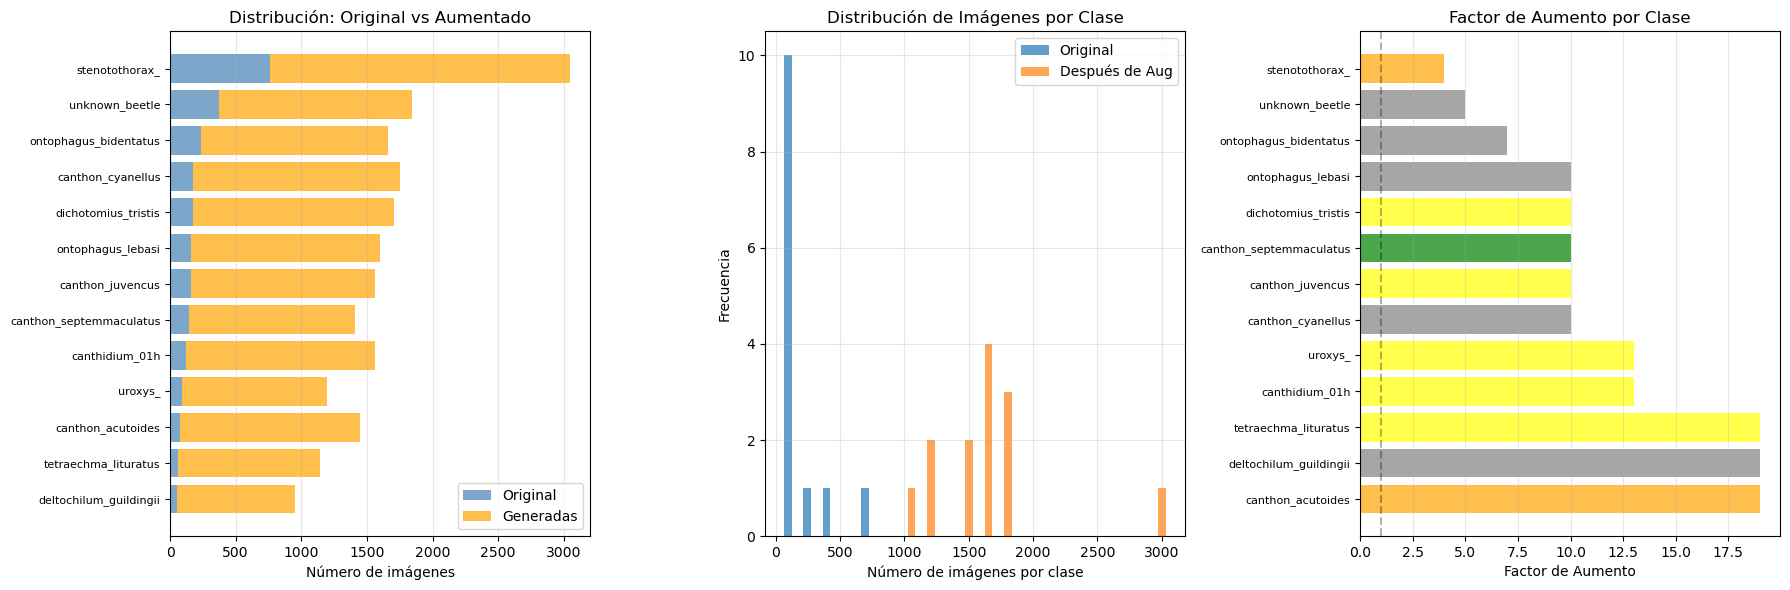


📊 MÉTRICAS DE BALANCE DEL DATASET
------------------------------------------------------------
Desviación estándar (antes): 189.2
Desviación estándar (después): 504.6
Coeficiente de variación (antes): 0.96
Coeficiente de variación (después): 0.31
Rango (antes): 50 - 762
Rango (después): 950 - 3048
------------------------------------------------------------

✓ Resultados guardados en 'augmentation_results.csv'


In [12]:
if results is not None:
    import pandas as pd
    
    # Crear DataFrame
    df_results = pd.DataFrame(results)
    
    # Mostrar tabla de resultados
    print("\n📊 RESULTADOS DETALLADOS POR CLASE")
    print("=" * 115)
    print(f"{'Clase':35s} {'Original':>8s} {'Generadas':>10s} {'Total':>8s} {'Factor':>7s} {'Nivel':>20s} {'Especial':>8s}")
    print("-" * 115)
    
    for _, row in df_results.sort_values('original').iterrows():
        factor = row['total'] / row['original'] if row['original'] > 0 else 0
        special_mark = "⭐" if row.get('special_rule', False) else ""
        print(f"{row['class']:35s} {row['original']:8d} {row['augmented']:10d} {row['total']:8d} "
              f"{factor:7.1f}x {row['level']:>20s} {special_mark:>8s}")
    
    print("=" * 115)
    
    # Mostrar clases con reglas especiales
    special_classes = df_results[df_results.get('special_rule', False) == True]
    if len(special_classes) > 0:
        print("\n🎯 CLASES CON REGLAS ESPECIALES:")
        print("-" * 80)
        for _, row in special_classes.iterrows():
            print(f"   {row['class']:30s}: {row['num_aug_per_img']} variantes [{row['level']}]")
        print("-" * 80)
    
    # Estadísticas por nivel
    print("\n📈 ESTADÍSTICAS POR NIVEL DE AUGMENTATION")
    print("-" * 60)
    level_stats = df_results.groupby('level').agg({
        'original': 'sum',
        'augmented': 'sum',
        'total': 'sum'
    })
    
    for level, stats in level_stats.iterrows():
        factor = stats['total'] / stats['original'] if stats['original'] > 0 else 0
        print(f"{level:15s}: {stats['original']:5.0f} → {stats['total']:6.0f} imágenes ({factor:.1f}x)")
    
    print("-" * 60)
    
    # Visualización comparativa
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Gráfico 1: Antes vs Después
    ax1 = axes[0]
    sorted_df = df_results.sort_values('original')
    x = range(len(sorted_df))
    ax1.barh(x, sorted_df['original'], alpha=0.7, label='Original', color='steelblue')
    ax1.barh(x, sorted_df['augmented'], left=sorted_df['original'], 
             alpha=0.7, label='Generadas', color='orange')
    ax1.set_yticks(x)
    ax1.set_yticklabels(sorted_df['class'], fontsize=8)
    ax1.set_xlabel('Número de imágenes')
    ax1.set_title('Distribución: Original vs Aumentado')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Gráfico 2: Comparación de distribuciones
    ax2 = axes[1]
    ax2.hist([df_results['original'], df_results['total']], 
             bins=20, label=['Original', 'Después de Aug'], alpha=0.7)
    ax2.set_xlabel('Número de imágenes por clase')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title('Distribución de Imágenes por Clase')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Gráfico 3: Factor de aumento por clase
    ax3 = axes[2]
    df_results['factor'] = df_results['total'] / df_results['original']
    colors_map = {
        'aggressive': 'red',
        'moderate': 'orange',
        'moderate-light': 'yellow',
        'light': 'green'
    }
    colors = [colors_map.get(level, 'gray') for level in df_results['level']]
    
    sorted_by_factor = df_results.sort_values('factor', ascending=False)
    ax3.barh(range(len(sorted_by_factor)), sorted_by_factor['factor'], color=colors, alpha=0.7)
    ax3.set_yticks(range(len(sorted_by_factor)))
    ax3.set_yticklabels(sorted_by_factor['class'], fontsize=8)
    ax3.set_xlabel('Factor de Aumento')
    ax3.set_title('Factor de Aumento por Clase')
    ax3.axvline(1, color='black', linestyle='--', alpha=0.3)
    ax3.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Métricas de balance
    print("\n📊 MÉTRICAS DE BALANCE DEL DATASET")
    print("-" * 60)
    print(f"Desviación estándar (antes): {df_results['original'].std():.1f}")
    print(f"Desviación estándar (después): {df_results['total'].std():.1f}")
    print(f"Coeficiente de variación (antes): {df_results['original'].std() / df_results['original'].mean():.2f}")
    print(f"Coeficiente de variación (después): {df_results['total'].std() / df_results['total'].mean():.2f}")
    print(f"Rango (antes): {df_results['original'].min()} - {df_results['original'].max()}")
    print(f"Rango (después): {df_results['total'].min()} - {df_results['total'].max()}")
    print("-" * 60)
    
    # Guardar resultados
    df_results.to_csv('augmentation_results.csv', index=False)
    print("\n✓ Resultados guardados en 'augmentation_results.csv'")
else:
    print("⚠️  No hay resultados para analizar. Ejecuta primero el proceso de augmentation.")

## 9. Verificación Final del Dataset Aumentado

In [13]:
# Verificar el dataset final en la carpeta de aumentadas
final_distribution = analyze_dataset(OUTPUT_DIR, only_original=False)

print("\n🎯 DISTRIBUCIÓN FINAL DEL DATASET AUMENTADO")
print("=" * 80)
print(f"{'Clase':35s} {'Imágenes':>10s}")
print("-" * 80)
for class_name, count in sorted(final_distribution.items(), key=lambda x: x[1]):
    print(f"{class_name:35s} {count:10d}")
print("-" * 80)
print(f"Total de géneros: {len(final_distribution)}")
print(f"Total de imágenes aumentadas: {sum(final_distribution.values()):,}")
print(f"Promedio por clase: {np.mean(list(final_distribution.values())):.1f}")
print(f"Mediana por clase: {np.median(list(final_distribution.values())):.1f}")
print(f"Desviación estándar: {np.std(list(final_distribution.values())):.1f}")
print(f"Min: {min(final_distribution.values())}, Max: {max(final_distribution.values())}")
print("=" * 80)
print(f"\n📂 Carpeta originales: {DATA_DIR}")
print(f"📂 Carpeta aumentadas: {OUTPUT_DIR}")


🎯 DISTRIBUCIÓN FINAL DEL DATASET AUMENTADO
Clase                                 Imágenes
--------------------------------------------------------------------------------
deltochilum_guildingii                     900
tetraechma_lituratus                      1080
uroxys_                                   1104
canthon_septemmaculatus                   1269
canthon_acutoides                         1368
canthon_juvencus                          1404
ontophagus_bidentatus                     1422
canthidium_01h                            1440
ontophagus_lebasi                         1440
unknown_beetle                            1476
dichotomius_tristis                       1539
canthon_cyanellus                         1575
stenotothorax_                            2286
--------------------------------------------------------------------------------
Total de géneros: 13
Total de imágenes aumentadas: 18,303
Promedio por clase: 1407.9
Mediana por clase: 1422.0
Desviación estándar: 316.

## 10. Visualización de Muestras Aleatorias del Dataset Aumentado

🖼️  VISUALIZACIÓN DE MUESTRAS AUMENTADAS



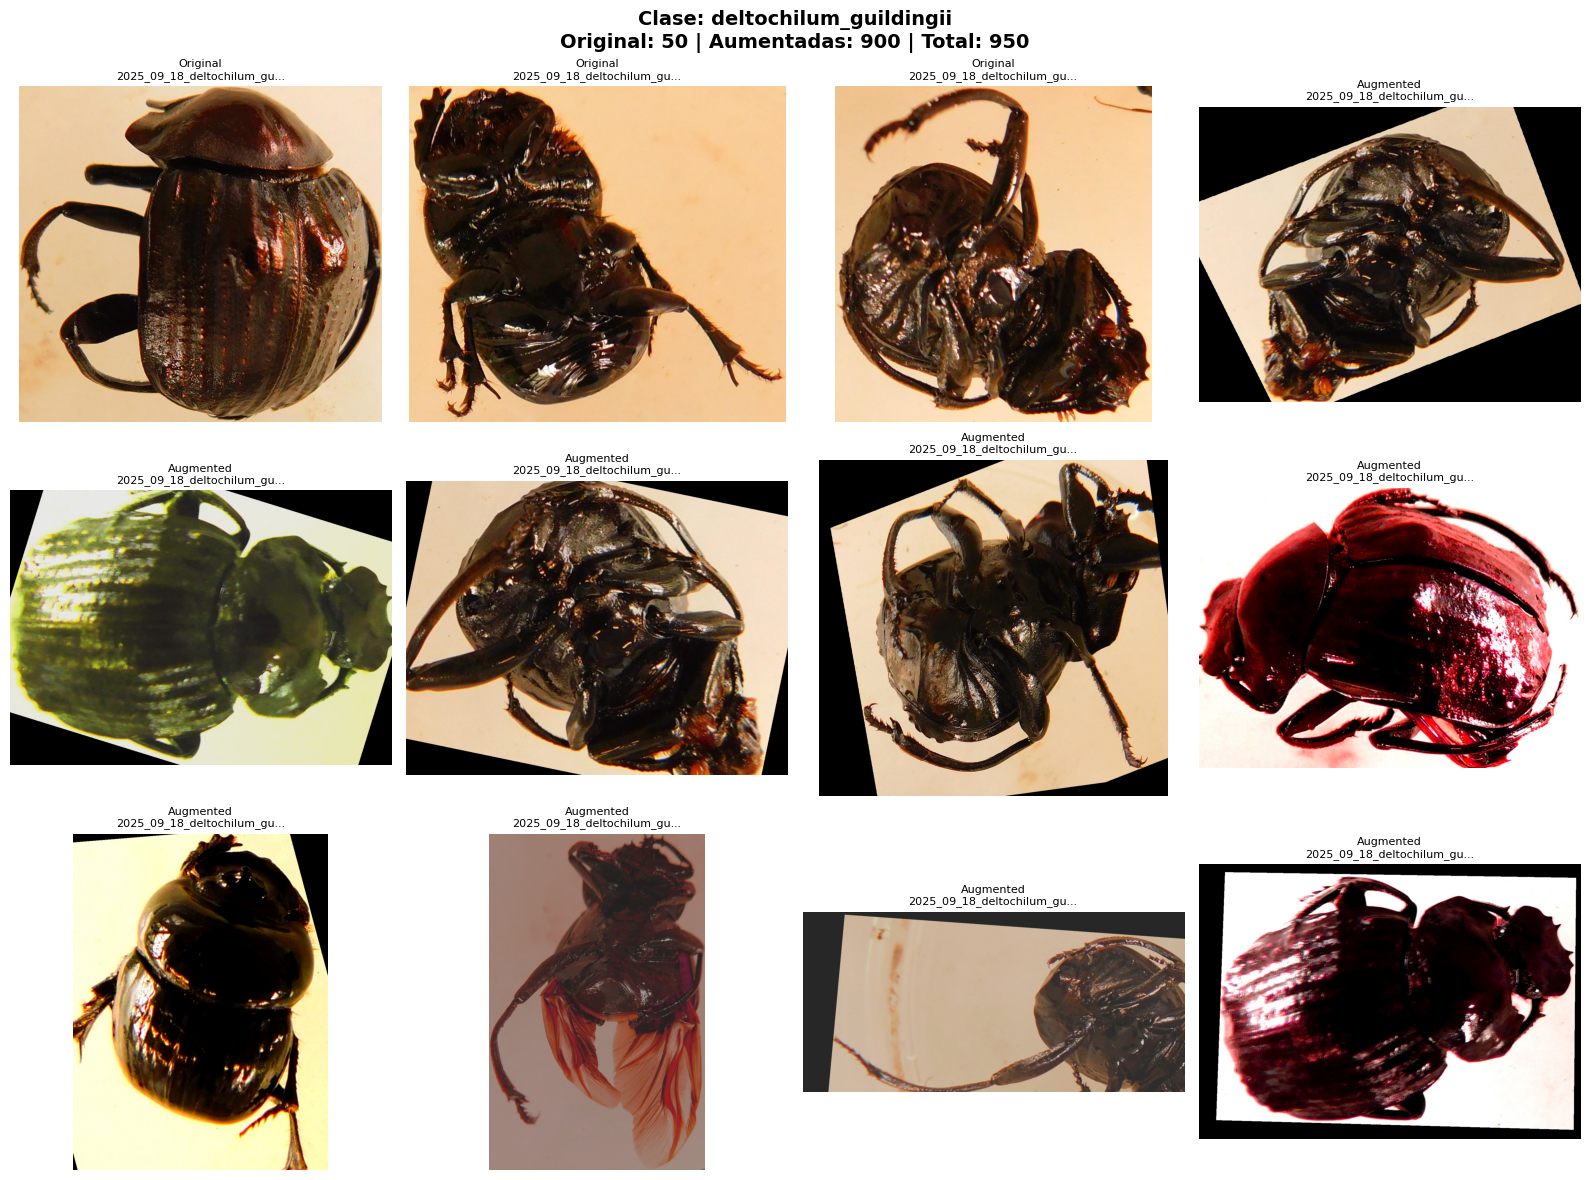

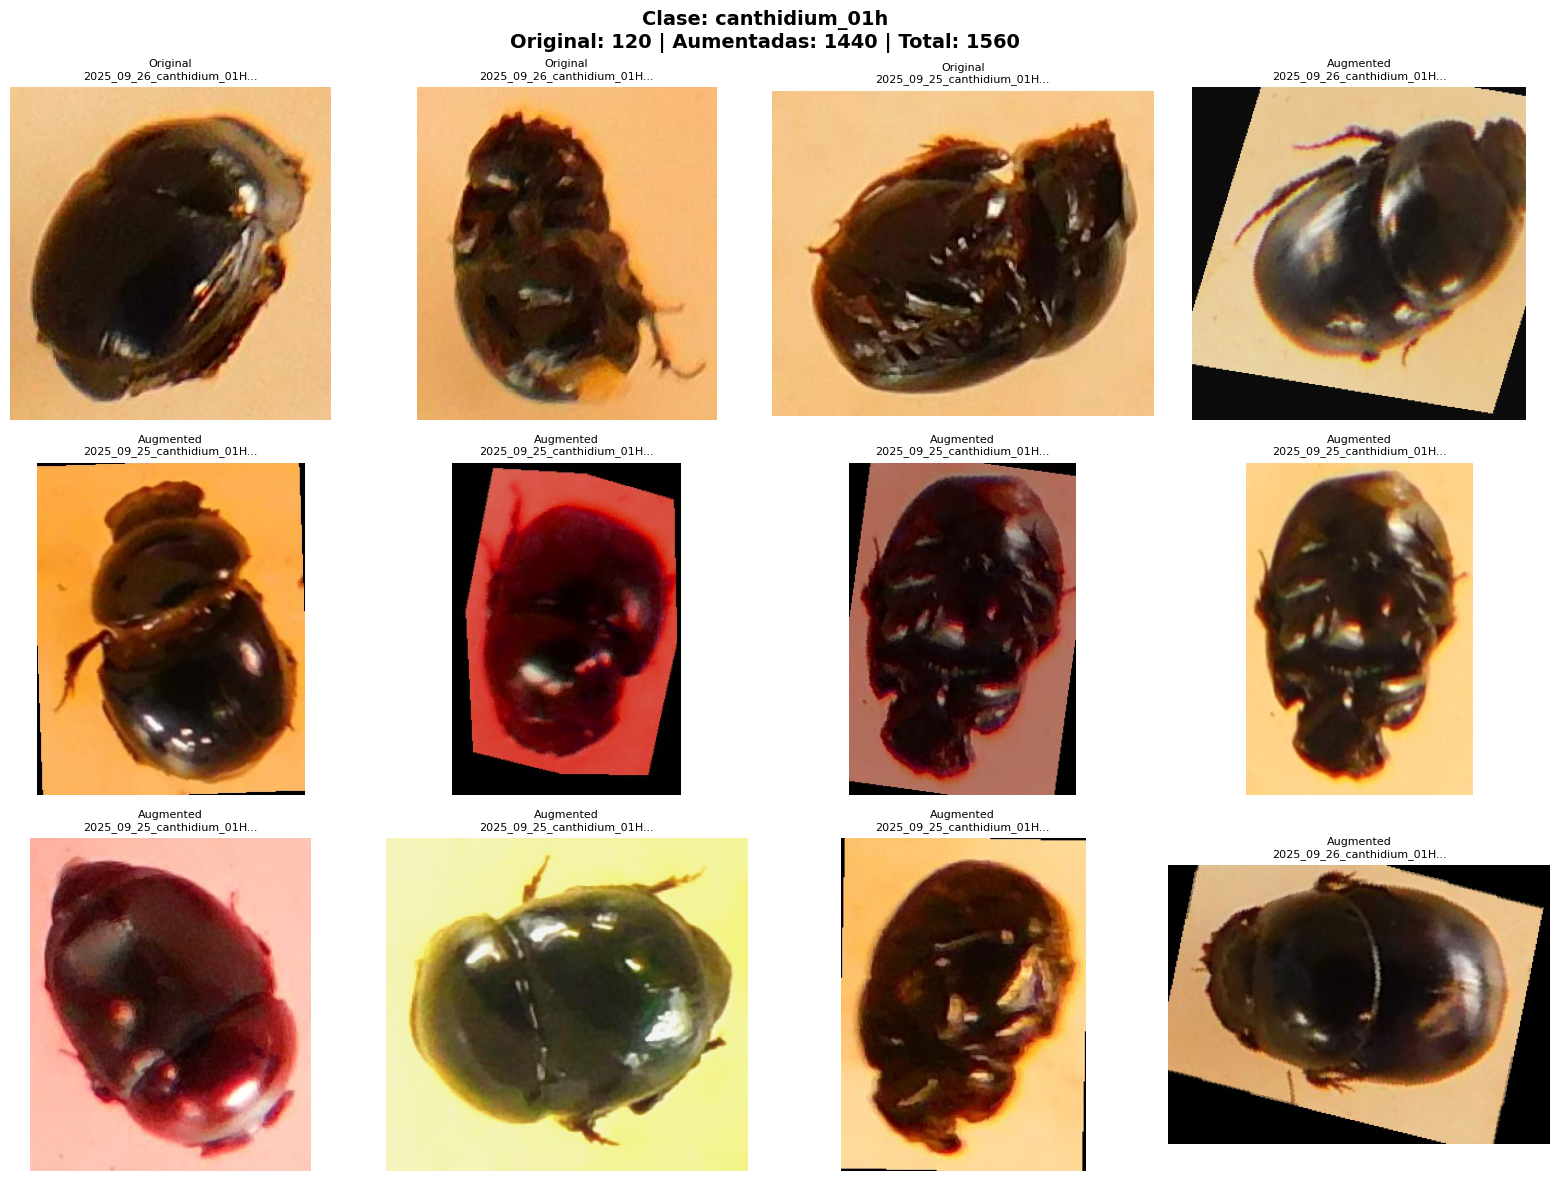

In [14]:
def visualize_augmented_samples(class_name, num_samples=12):
    """
    Visualiza muestras aleatorias de una clase después del augmentation
    """
    # Buscar en la carpeta de AUMENTADAS
    class_path = os.path.join(OUTPUT_DIR, class_name)
    
    # Si no existe la carpeta de aumentadas, buscar en originales
    if not os.path.exists(class_path):
        print(f"⚠️  No se encontró la carpeta aumentada para {class_name}")
        return
    
    # Obtener todas las imágenes aumentadas
    all_images = [f for f in os.listdir(class_path) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(all_images) == 0:
        print(f"No se encontraron imágenes aumentadas en {class_name}")
        return
    
    # También obtener originales para comparación
    orig_class_path = os.path.join(DATA_DIR, class_name)
    original_images = [f for f in os.listdir(orig_class_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                      and '_aug_' not in f]
    
    # Seleccionar muestras
    sample_original = random.sample(original_images, min(3, len(original_images)))
    sample_augmented = random.sample(all_images, min(num_samples-3, len(all_images)))
    
    
    # Visualizar
    rows = 3
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
    axes = axes.flatten()
    
    # Mostrar originales primero
    for idx, img_file in enumerate(sample_original):
        img_path = os.path.join(orig_class_path, img_file)
        img = Image.open(img_path)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f"Original\n{img_file[:25]}...", fontsize=8)
        axes[idx].axis('off')
    
    # Luego mostrar aumentadas
    for idx, img_file in enumerate(sample_augmented, start=len(sample_original)):
        if idx >= num_samples:
            break
        img_path = os.path.join(class_path, img_file)
        img = Image.open(img_path)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f"Augmented\n{img_file[:25]}...", fontsize=8)
        axes[idx].axis('off')
    
    # Ocultar ejes sobrantes
    for idx in range(len(sample_original) + len(sample_augmented), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Clase: {class_name}\n'
                 f'Original: {len(original_images)} | Aumentadas: {len(all_images)} | '
                 f'Total: {len(original_images) + len(all_images)}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualizar algunas clases
print("🖼️  VISUALIZACIÓN DE MUESTRAS AUMENTADAS\n")

# Seleccionar clases para visualizar
classes_to_visualize = []

# Clase con muy pocas imágenes
for class_name, count in sorted(class_dist.items(), key=lambda x: x[1])[:3]:
    if count <= 5:
        classes_to_visualize.append(class_name)

# Clase con pocas imágenes
for class_name, count in class_dist.items():
    if 30 <= count <= 60:
        classes_to_visualize.append(class_name)
        break

# Clase con cantidad media
for class_name, count in class_dist.items():
    if 100 <= count <= 150:
        classes_to_visualize.append(class_name)
        break

# Visualizar
for class_name in classes_to_visualize[:3]:
    visualize_augmented_samples(class_name)

## 11. Verificación de la Configuración de unknown_beetle

🔍 VERIFICACIÓN DE CONFIGURACIÓN: unknown_beetle

Prueba de configuración para unknown_beetle con diferentes tamaños:
--------------------------------------------------------------------------------
     Cantidad de Imágenes       Nivel Asignado   Num. Aumentaciones
--------------------------------------------------------------------------------
                       50           very-light                    4
                      100           very-light                    4
                      200           very-light                    4
                      500           very-light                    4
                     1000           very-light                    4
--------------------------------------------------------------------------------

✅ Confirmación:
   unknown_beetle siempre recibirá 4 variantes con transformaciones 'very-light'
   independientemente del número de imágenes que tenga.

📊 Estado actual de unknown_beetle:
   Imágenes actuales: 369
   Nivel asignad

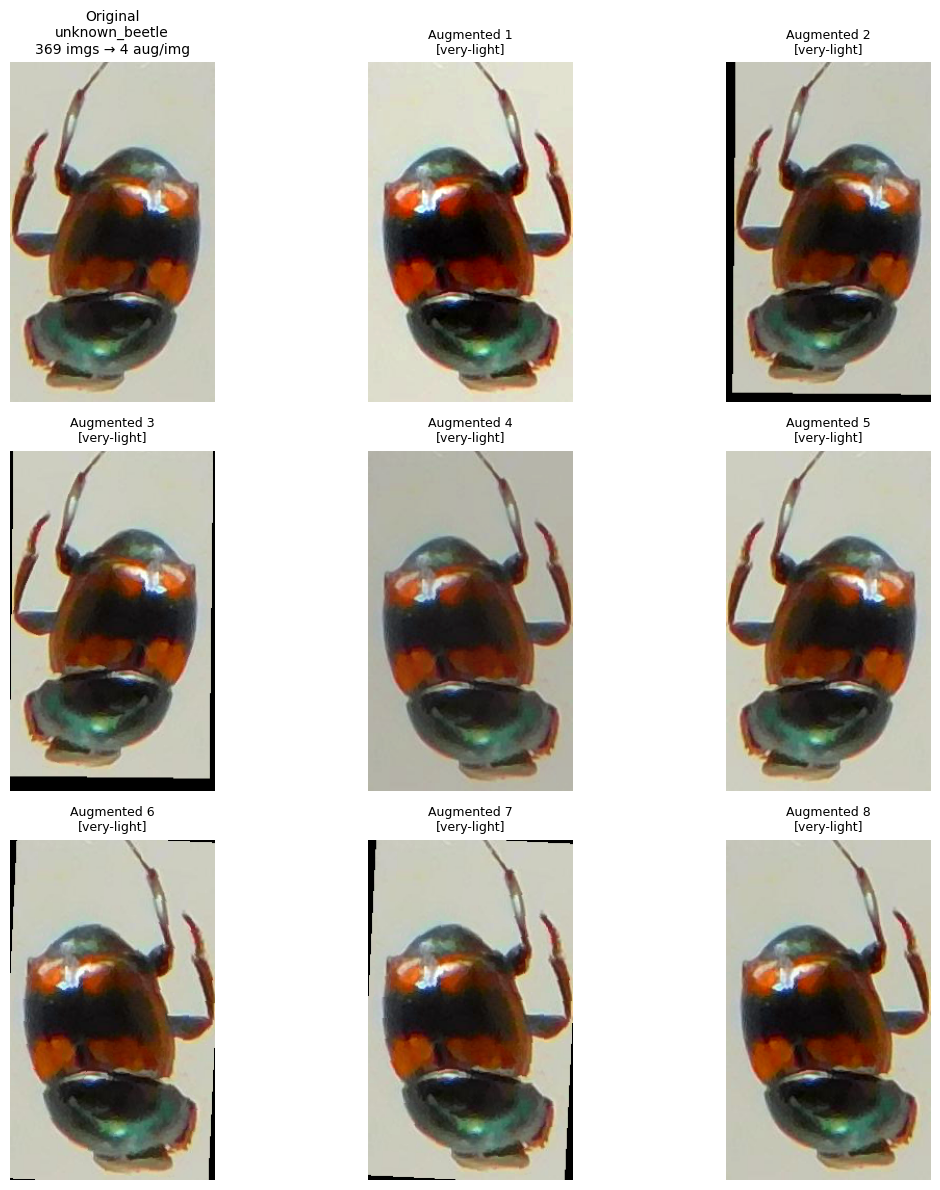

Clase: unknown_beetle
Imágenes originales: 369
Nivel de augmentation: very-light
Variantes por imagen: 4
Total imágenes después: 1845
------------------------------------------------------------


In [15]:
# Verificar la configuración de unknown_beetle
print("=" * 80)
print("🔍 VERIFICACIÓN DE CONFIGURACIÓN: unknown_beetle")
print("=" * 80)

# Simular diferentes cantidades de imágenes para unknown_beetle
test_counts = [50, 100, 200, 500, 1000]

print("\nPrueba de configuración para unknown_beetle con diferentes tamaños:")
print("-" * 80)
print(f"{'Cantidad de Imágenes':>25s} {'Nivel Asignado':>20s} {'Num. Aumentaciones':>20s}")
print("-" * 80)

for count in test_counts:
    level, num_aug = get_augmentation_level('unknown_beetle', count)
    print(f"{count:>25d} {level:>20s} {num_aug:>20d}")

print("-" * 80)
print("\n✅ Confirmación:")
print("   unknown_beetle siempre recibirá 4 variantes con transformaciones 'very-light'")
print("   independientemente del número de imágenes que tenga.")
print("=" * 80)

# Verificar si unknown_beetle existe en el dataset
if 'unknown_beetle' in class_dist:
    actual_count = class_dist['unknown_beetle']
    level, num_aug = get_augmentation_level('unknown_beetle', actual_count)
    
    print(f"\n📊 Estado actual de unknown_beetle:")
    print(f"   Imágenes actuales: {actual_count}")
    print(f"   Nivel asignado: {level}")
    print(f"   Aumentaciones: {num_aug}")
    print(f"   Total después de augmentation: {actual_count * (1 + num_aug)}")
    print("=" * 80)
    
    # Previsualizar si existe
    if actual_count > 0:
        print("\n🖼️  Previsualizando transformaciones para unknown_beetle:\n")
        preview_augmentations('unknown_beetle')
else:
    print("\n⚠️  La clase 'unknown_beetle' no se encuentra en el dataset actual.")
    print("   Cuando agregues esta clase, automáticamente se aplicará la regla especial.")
    print("=" * 80)

---

## 📋 Resumen de la Estrategia Optimizada

### **Configuración Adaptativa por Umbral:**

| Umbral | Variantes | Nivel | Descripción |
|--------|-----------|-------|-------------|
| ≤80 imgs | 18 | moderate-strong | Clases pequeñas - Aumentar significativamente |
| ≤120 imgs | 12 | moderate | Clases medianas-pequeñas |
| ≤180 imgs | 9 | moderate-light | Clases medianas |
| ≤400 imgs | 6 | light | Clases grandes |
| >400 imgs | 3 | very-light | Clases muy grandes |

### **Regla Especial:**

- **`unknown_beetle`**: 4 variantes con transformaciones `very-light`
  - Independiente del número de imágenes
  - Transformaciones conservadoras para clase heterogénea
  - Evita confundir al modelo con variaciones excesivas

